In [46]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from IPython.display import Image
from dotenv import load_dotenv
import operator

load_dotenv()

True

`UPSC essay evaluation`  
- start :
    - upsc essay

- parallel nodes :
    - clarity of thought (CoT) :
        - LLM 
            1. text feedback
            2. score (0 - 10)

    - depth of analysis (DoA) :
        - LLM
            1. text feedback
            2. score (0 - 10)

    - language :
        - LLM
            1. text feedback
            2. score (0 - 10)

- final evaluation node :
    - LLM
        1. summarize feedback
        2. calculate average of scores

In [47]:
model = ChatGroq(model = "llama-3.3-70b-versatile")

In [48]:
# pydantic schema
def EvaluationSchema(BaseModel) :
    feedback : str = Field(description="detailed feedback for essay")
    score : int = Field(description= "score out of 10", ge=0, le= 10)

In [49]:
model_with_struct_output = model.with_structured_output(EvaluationSchema)

In [50]:
essay = """" 
The Power of Pages: Why Reading Books MattersReading books is one of the most powerful habits a person can build. It acts as a gateway to new worlds, ideas, and perspectives. While digital media offers quick snippets of information, books provide deep knowledge and lasting mental benefits.Mental Growth and FocusBoosts Brain Power: Reading exercises your brain, keeping your mind sharp and active.Improves Concentration: Following a book's narrative trains your mind to focus on a single task.Reduces Stress: Immersing yourself in a story lowers your heart rate and helps you relax.Language and KnowledgeExpands Vocabulary: Exposure to well-written text naturally introduces new words and phrases.Enhances Communication: Better vocabulary leads to clearer speaking and writing skills.Builds Deep Knowledge: Books explore topics thoroughly, giving you a better understanding of the world.Empathy and CreativitySparks Imagination: Visualizing stories in your mind builds creative thinking.Teaches Empathy: Reading about different cultures and experiences helps you understand other people's feelings.ConclusionBooks are more than just paper and ink; they are tools for personal growth. Reading shapes your mind, builds your skills, and widens your perspective. Making time to read every day is an investment in your own future.To customize this, let me know the word count you need or if you want to focus on a specific age group like children or adults.
"""

In [51]:
prompt = f'evaluate the language quality of following essay and provide a feedback and assign a score out of 10 \n{essay}'

response = model_with_struct_output.invoke(prompt)

In [52]:
print(response['BaseModel']['score'])
print(response['BaseModel']['feedback'])

8
The essay is well-structured and effectively conveys the importance of reading books. The use of headings and subheadings makes it easy to follow, and the language is clear and concise. However, the essay could benefit from more nuanced and detailed explanations of the benefits of reading, as well as more varied and sophisticated sentence structures. Additionally, the conclusion could be stronger and more impactful.


In [53]:
model.invoke(prompt)

AIMessage(content='**Language Quality Evaluation and Feedback**\n\nThe essay "The Power of Pages: Why Reading Books Matters" demonstrates a clear and concise writing style, effectively conveying the importance of reading books. Here\'s a breakdown of the language quality:\n\n**Strengths:**\n\n1. **Clear structure**: The essay follows a logical and easy-to-follow structure, dividing the benefits of reading into three main categories: Mental Growth and Focus, Language and Knowledge, and Empathy and Creativity.\n2. **Concise language**: The writer uses simple and straightforward language, making the text accessible to a wide range of readers.\n3. **Effective use of transitions**: The essay uses transitional phrases and words (e.g., "Boosts Brain Power", "Expands Vocabulary", "Sparks Imagination") to connect ideas and paragraphs.\n\n**Weaknesses:**\n\n1. **Lack of depth and analysis**: The essay primarily presents a list of benefits without delving deeper into each point or providing suppo

In [54]:
# state schema
class UPSCState(TypedDict) :
    essay : str
    language_feedback : str
    analysis_feedback : str 
    clarity_feedback : str 
    overall_feedback : str
    individual_scores : Annotated[list[int], operator.add]
    average_score : float

In [55]:
def evaluate_language(state:UPSCState):
    prompt = f'evaluate the language quality of following essay and provide a feedback and assign a score out of 10 \n{state["essay"]}'
    response = model_with_struct_output.invoke(prompt)
    
    return {
        'language_feedback': response['BaseModel']['feedback'], 
        'individual_scores': [response['BaseModel']['score']]
            }

In [56]:
def evaluate_analysis(state:UPSCState):
    prompt = f'evaluate the depth of analysis of following essay and provide a feedback and assign a score out of 10 \n{state["essay"]}'
    response = model_with_struct_output.invoke(prompt)
    
    return {
        'analysis_feedback': response['BaseModel']['feedback'], 
        'individual_scores': [response['BaseModel']['score']]
            }

In [57]:
def evaluate_thought(state:UPSCState):
    prompt = f'evaluate the clarity of thought of following essay and provide a feedback and assign a score out of 10 \n{state["essay"]}'
    response = model_with_struct_output.invoke(prompt)
    
    return {
        'clarity_feedback': response['BaseModel']['feedback'], 
        'individual_scores': [response['BaseModel']['score']]
            }

In [58]:
def final_evaluation(state:UPSCState):
    # summary feedback
    prompt = f"based on the following feedbacks create a summarized feedback \n language feedback - {state['language_feedback']}\n depth of analysis - {state['analysis_feedback']} \n clarity of thought - {state['clarity_feedback']}"
    response = model.invoke(prompt)
    
    # average_score
    average_score = sum(state['individual_scores']) / len(state['individual_scores'])
    return {
        "overall_feedback" : response.content,
        "average_score" : round(average_score, 2)
            }

In [59]:
# define graph
graph = StateGraph(UPSCState)

# add nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

In [60]:
# add edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

In [61]:
workflow = graph.compile()

In [62]:
workflow.invoke({'essay' : essay})

{'essay': '" \nThe Power of Pages: Why Reading Books MattersReading books is one of the most powerful habits a person can build. It acts as a gateway to new worlds, ideas, and perspectives. While digital media offers quick snippets of information, books provide deep knowledge and lasting mental benefits.Mental Growth and FocusBoosts Brain Power: Reading exercises your brain, keeping your mind sharp and active.Improves Concentration: Following a book\'s narrative trains your mind to focus on a single task.Reduces Stress: Immersing yourself in a story lowers your heart rate and helps you relax.Language and KnowledgeExpands Vocabulary: Exposure to well-written text naturally introduces new words and phrases.Enhances Communication: Better vocabulary leads to clearer speaking and writing skills.Builds Deep Knowledge: Books explore topics thoroughly, giving you a better understanding of the world.Empathy and CreativitySparks Imagination: Visualizing stories in your mind builds creative think

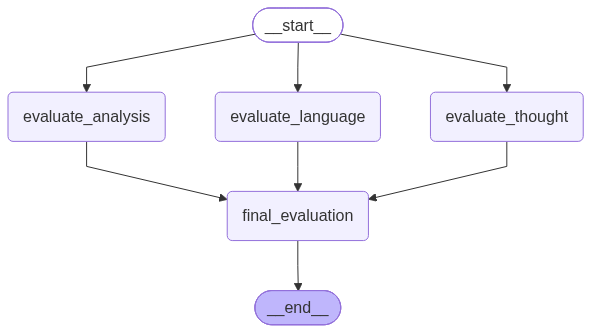

In [63]:
Image(workflow.get_graph().draw_mermaid_png())

In [64]:
essay2 = """ 
Corruption is Very Bad ProblemCorruption is a thing that happens in everywhere and it is making the peoples very angry all the time. Money is going to bad places because the government guys are taking it for buying big cars and houses while poor peoples have no food or schools for their childrens.Why It Is HappeningNo Money: People don't have good cash so they take the extra cash from anyone who gives it.Bad Rules: Police is not catching the bad guys because they also want some money for secret pockets.Systems: Everything is broken and you must wait in a long line unless you give a bribe to the desk man.More Things About ThisIt is also killing the roads because the cement is very cheap and then the rain comes and makes huge holes. Nobody likes holes but the builders are friends with the big boss so nothing happens. If you want to get a job you need a cousin who works there or you just sit at home doing nothing. It is a very sad circle that goes round and round.Last WordsWe must stop this thing immediately today because it is not fair for the country. If everyone is honest then the world will be nice and beautiful for everyone.To adjust this further, let me know if you want it to be longer or if you need more grammar mistakes mixed in!"""

In [65]:
workflow.invoke({'essay':essay2})

{'essay': " \nCorruption is Very Bad ProblemCorruption is a thing that happens in everywhere and it is making the peoples very angry all the time. Money is going to bad places because the government guys are taking it for buying big cars and houses while poor peoples have no food or schools for their childrens.Why It Is HappeningNo Money: People don't have good cash so they take the extra cash from anyone who gives it.Bad Rules: Police is not catching the bad guys because they also want some money for secret pockets.Systems: Everything is broken and you must wait in a long line unless you give a bribe to the desk man.More Things About ThisIt is also killing the roads because the cement is very cheap and then the rain comes and makes huge holes. Nobody likes holes but the builders are friends with the big boss so nothing happens. If you want to get a job you need a cousin who works there or you just sit at home doing nothing. It is a very sad circle that goes round and round.Last WordsW